# Coffee Shop Daily Revenue Prediction

**Dataset Overview**

This dataset contains 2,000 rows of data from coffee shops, offering detailed insights into factors that influence daily revenue. It includes key operational and environmental variables that provide a comprehensive view of how business activities and external conditions affect sales performance. Designed for use in predictive analytics and business optimization, this dataset is a valuable resource for anyone looking to understand the relationship between customer behavior, operational decisions, and revenue generation in the food and beverage industry.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/coffee-shop-daily-revenue-prediction-dataset/coffee_shop_revenue.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings("ignore")

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

Note: you may need to restart the kernel to use updated packages.


# Dataset Information

Number of Customers Per Day

    The total number of customers visiting the coffee shop on any given day.
    Range: 50 - 500 customers.
    
Average Order Value ($)
    
    The average dollar amount spent by each customer during their visit. 
    Range: $2.50 - $10.00.
    
Operating Hours Per Day

    The total number of hours the coffee shop is open for business each day.
    Range: 6 - 18 hours.
    
Number of Employees
    
    The number of employees working on a given day. This can influence service speed, customer satisfaction, and ultimately, sales.
    Range: 2 - 15 employees.
    
Marketing Spend Per Day ($)
    
    The amount of money spent on marketing campaigns or promotions on any given day.
    Range: $10 - $500 per day.

Location Foot Traffic (people/hour)

    The number of people passing by the coffee shop per hour
    a variable indicative of the shop's location and its potential to attract customers.
    Range: 50 - 1000 people per hour.

Daily Revenue ($)

    Target variable

In [3]:
df = pd.read_csv('/kaggle/input/coffee-shop-daily-revenue-prediction-dataset/coffee_shop_revenue.csv')
print(df)

      Number_of_Customers_Per_Day  Average_Order_Value  \
0                             152                 6.74   
1                             485                 4.50   
2                             398                 9.09   
3                             320                 8.48   
4                             156                 7.44   
...                           ...                  ...   
1995                          372                 6.41   
1996                          105                 3.01   
1997                           89                 5.28   
1998                          403                 9.41   
1999                           89                 6.88   

      Operating_Hours_Per_Day  Number_of_Employees  Marketing_Spend_Per_Day  \
0                          14                    4                   106.62   
1                          12                    8                    57.83   
2                           6                    6                

In [4]:
df.sample(5)

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
17,180,8.69,17,14,495.90,656,2167.08
1674,443,2.59,17,8,42.14,535,1215.17
316,312,7.44,14,11,219.50,808,2656.69
1361,64,4.00,11,4,313.11,93,673.55
1183,278,8.66,16,10,246.70,165,2601.32


In [5]:
print("Shape:",df.shape)
display(df.info())
display(df.describe().T)

Shape: (2000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


None

,count,mean,std,min,25%,50%,75%,max
Number_of_Customers_Per_Day,2000.0,274.296000,129.441933,50.00,164.000,275.000,386.0000,499.00
Average_Order_Value,2000.0,6.261215,2.175832,2.50,4.410,6.300,8.1200,10.00
Operating_Hours_Per_Day,2000.0,11.667000,3.438608,6.00,9.000,12.000,15.0000,17.00
Number_of_Employees,2000.0,7.947000,3.742218,2.00,5.000,8.000,11.0000,14.00
Marketing_Spend_Per_Day,2000.0,252.614160,141.136004,10.12,130.125,250.995,375.3525,499.74
Location_Foot_Traffic,2000.0,534.893500,271.662295,50.00,302.000,540.000,767.0000,999.00
Daily_Revenue,2000.0,1917.325940,976.202746,-58.95,1140.085,1770.775,2530.4550,5114.60


In [6]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
Number_of_Customers_Per_Day    0
Average_Order_Value            0
Operating_Hours_Per_Day        0
Number_of_Employees            0
Marketing_Spend_Per_Day        0
Location_Foot_Traffic          0
Daily_Revenue                  0
dtype: int64


# Data Distribution & Insights

**Impact of marketing spend on daily revenue**

**Correlation between customer volume and daily revenue**

Is staffing adequate? Is there redundancy?

Find the optimal staffing balance.

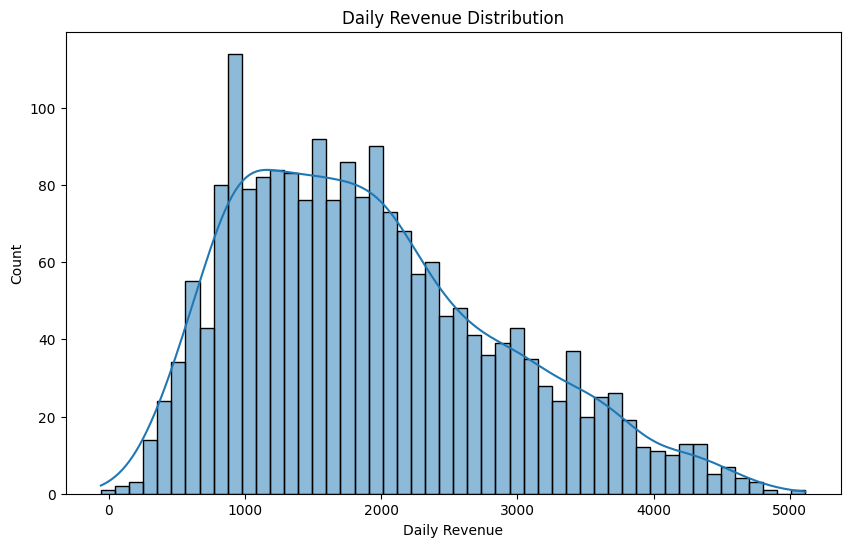

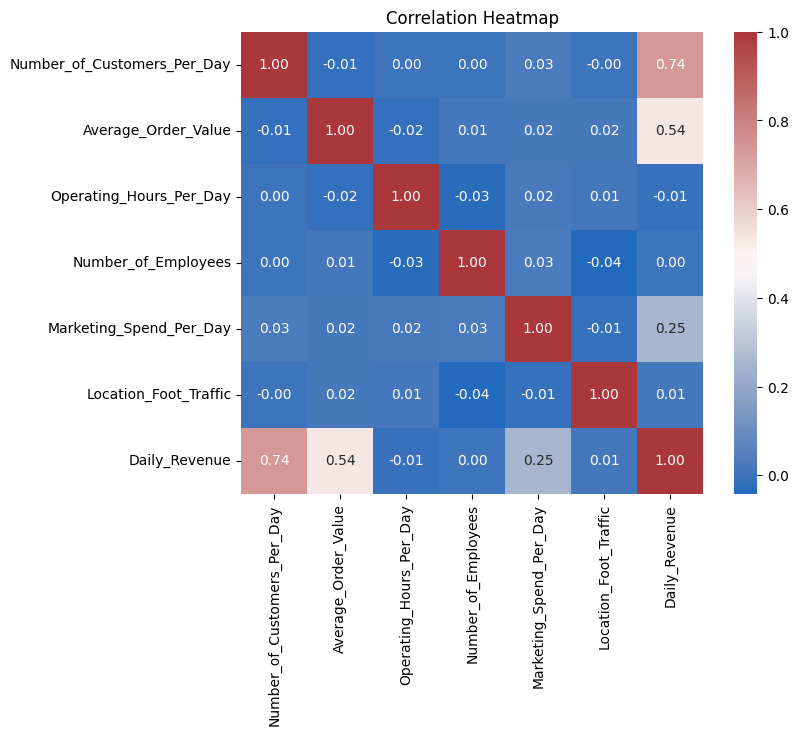

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(df['Daily_Revenue'], bins=50, kde=True)
plt.title("Daily Revenue Distribution")
plt.xlabel("Daily Revenue")
plt.show()

plt.figure(figsize=(8,6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", square=True)
plt.title("Correlation Heatmap")
plt.show()

**Relationship between external factors(like foot trafic) and customer behavior**

Does increased foot traffic genuinely attract more customers?
Is there a conversion rate?

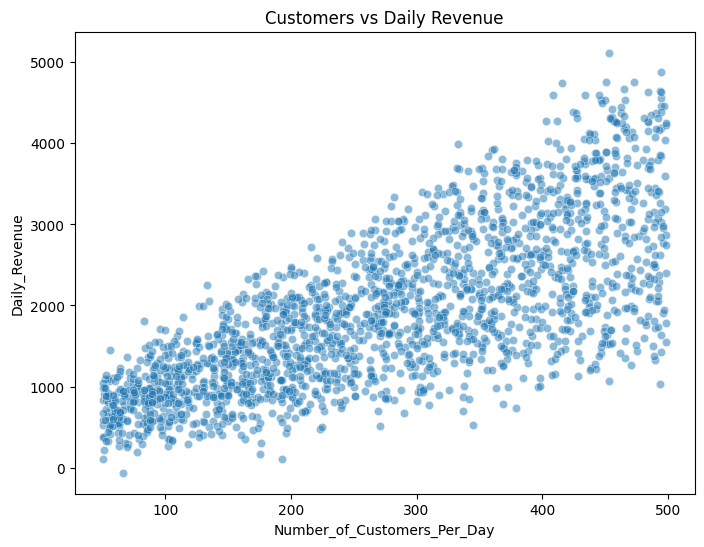

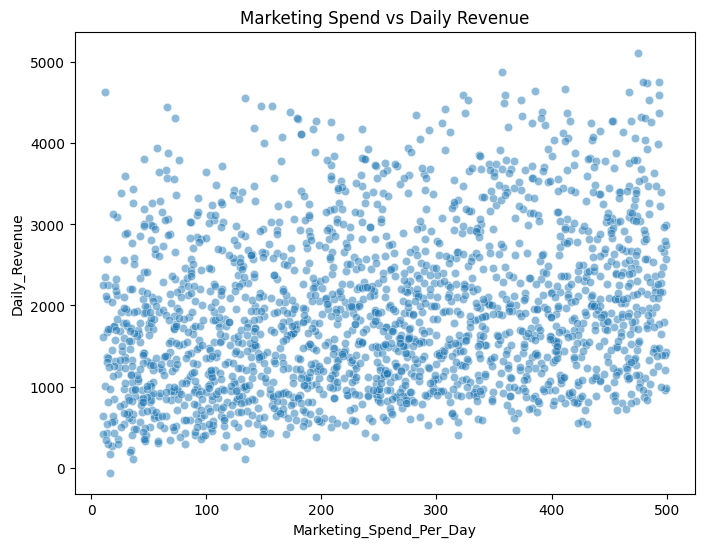

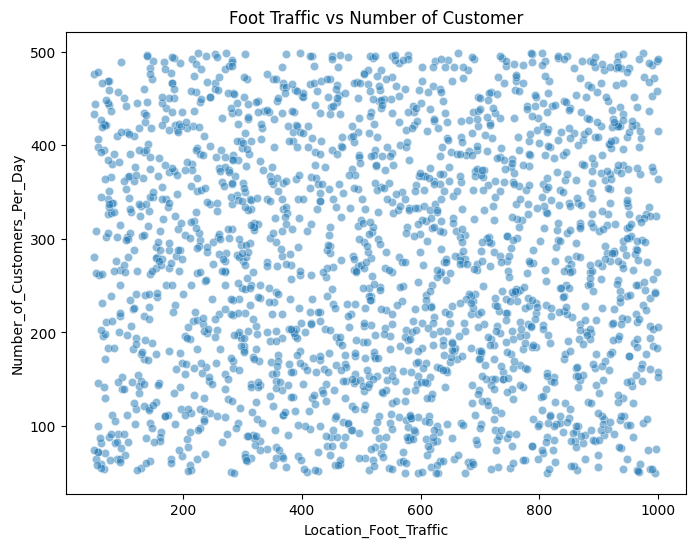

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Number_of_Customers_Per_Day', y = 'Daily_Revenue', 
                data = df, alpha = 0.5)
plt.title('Customers vs Daily Revenue')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x='Marketing_Spend_Per_Day', y = 'Daily_Revenue', 
                data = df, alpha = 0.5)
plt.title('Marketing Spend vs Daily Revenue')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x='Location_Foot_Traffic', y = 'Number_of_Customers_Per_Day', 
                data = df, alpha = 0.5)
plt.title('Foot Traffic vs Number of Customer')
plt.show()

Foot Traffic does not equate to customer 

**Feature Engineering**

In [9]:
df_fe = df.copy()
df_fe['rev_per_employee'] = df_fe['Daily_Revenue'] / df_fe['Number_of_Employees']
df_fe['effective_traffic'] = df_fe ['Location_Foot_Traffic'] * df_fe['Operating_Hours_Per_Day']
df_fe['marketing_per_customer'] = df_fe['Marketing_Spend_Per_Day'] / (df_fe['Number_of_Customers_Per_Day'] + 1)
df_fe['customer_spend'] = df_fe['Number_of_Customers_Per_Day'] * df_fe['Average_Order_Value']
df_fe['conversion_rate'] = df_fe['Number_of_Customers_Per_Day'] / df_fe['Location_Foot_Traffic']

df_fe['log_Daily_Revenue'] = np.log1p(df_fe['Daily_Revenue'])##for Skewed Distribution
display(df_fe[['rev_per_employee','effective_traffic','marketing_per_customer',
               'customer_spend','conversion_rate','log_Daily_Revenue']].describe().T)

,count,mean,std,min,25%,50%,75%,max
rev_per_employee,2000.0,333.924570,302.435236,-29.475000,134.545313,238.009643,417.249792,2185.50500
effective_traffic,2000.0,6254.068000,3790.580152,350.000000,3126.500000,5767.500000,8922.000000,16983.00000
marketing_per_customer,2000.0,1.283212,1.287191,0.023770,0.482621,0.908332,1.538955,9.79000
customer_spend,2000.0,1713.303160,1035.513668,149.060000,872.902500,1521.550000,2346.695000,4925.25000
conversion_rate,2000.0,0.835957,1.022195,0.050251,0.298240,0.511271,0.931207,9.52000
log_Daily_Revenue,1999.0,7.415714,0.567595,4.659658,7.040322,7.480220,7.836903,8.54005


In [10]:
feature_cols = [
    'Number_of_Customers_Per_Day', 'Average_Order_Value','Operating_Hours_Per_Day',
    'Number_of_Employees','Marketing_Spend_Per_Day','Location_Foot_Traffic',
    'rev_per_employee','effective_traffic','marketing_per_customer','customer_spend'
]

X = df_fe[feature_cols]
y = df_fe['Daily_Revenue']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state= 42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Multi-model Regression Comparison**

In [11]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=5000),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
    'MLP': MLPRegressor(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)
}

results = {}
for name,model in models.items():
    if name == 'RandomForest':
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    results[name] = {
        'RMSE': round(rmse(y_test, preds),2),
        'MAE': round(mean_absolute_error(y_test, preds),2),
        'R2': round(r2_score(y_test, preds),4)
    }

pd.DataFrame(results).T.sort_values('RMSE')

,RMSE,MAE,R2
RandomForest,181.90,141.09,0.9646
LinearRegression,193.27,158.04,0.9600
Lasso,193.27,158.04,0.9600
Ridge,193.32,158.11,0.9600
MLP,205.54,167.69,0.9548


Top features (RandomForest):


customer_spend                 0.912747
Marketing_Spend_Per_Day        0.038982
rev_per_employee               0.023040
marketing_per_customer         0.005935
Number_of_Employees            0.004870
Location_Foot_Traffic          0.003306
effective_traffic              0.003060
Number_of_Customers_Per_Day    0.002769
Operating_Hours_Per_Day        0.002698
Average_Order_Value            0.002596
dtype: float64

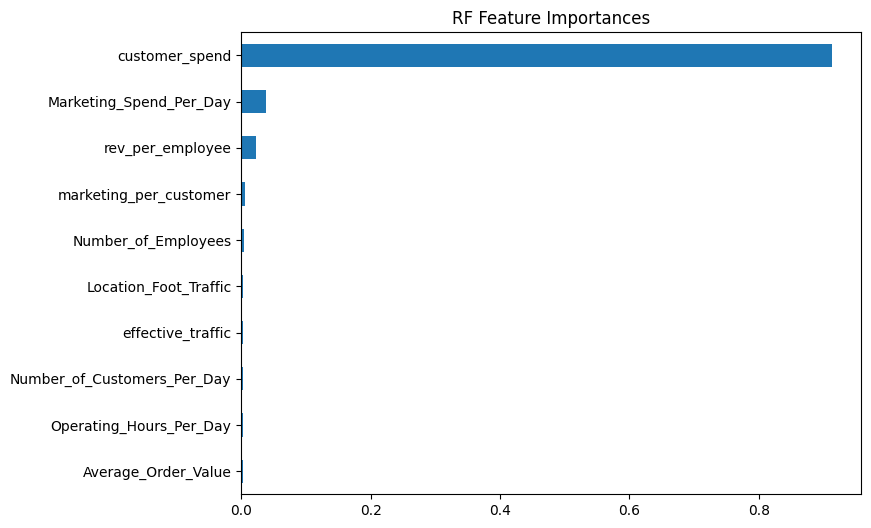

In [12]:
rf = models['RandomForest']
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top features (RandomForest):")
display(importances.head(15))

plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind='barh')
plt.title('RF Feature Importances')
plt.show()

# Use Case and Applications



**SHAP**

Is staffing adequate? Is there redundancy?

Find the optimal staffing balance.

Which characteristics most significantly impact revenue?

Does the effectiveness of marketing budgets differ between high-traffic and low-traffic periods?

Is there a diminishing return on the number of employees?

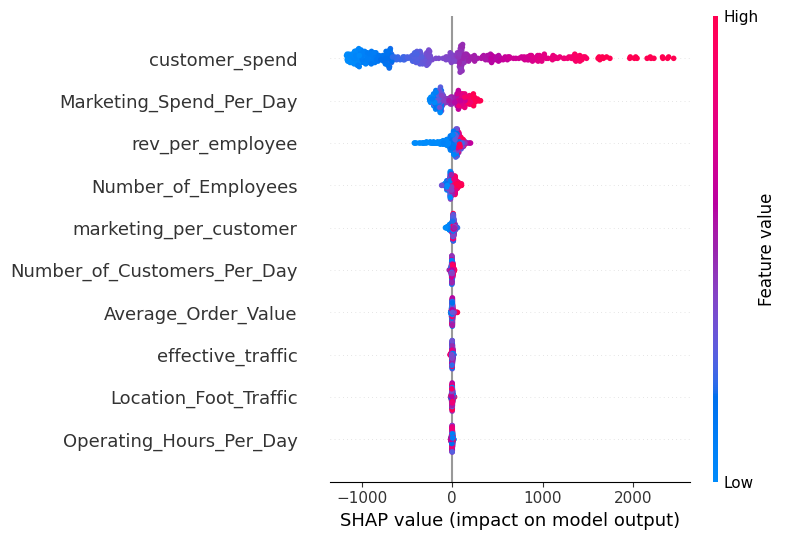

In [13]:

import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=True)


**SHAP horizontal span == the magnitude of a feature's contribution to the model prediction.**

**'customer_spend'**:   Average customer spend has a significantly greater impact on daily revenue than traffic-related or cost related variables.

*Suggests:     Increasing average transaction value generates revenue growth more directly than increasing traffic volume*

    Bundled Sales

    High-Profit Product Recommedations

    Tired VIP Pricing

    Value Bundles/Packages

**'marketing_spend_per_day'** :   Nonlinear(with budget saturation point)

Diminishing Marginal Return:

    Low marketing expenditure -- Significant SHAP increase (positive contribution)

    Moderate investment -- Continued growth, but diminishing marginal returns

    High investment -- SHAP distribution compression, or even decline

*Suggests :    SHAP reveals diminishing marginal returns in marketing expenditures - higher spending does not necessarily outperform moderate spending*

    ROI Curve Analysis

    Identify the 'optimal Marketing Spend Threshold'

    Avoid Wasting Ads Budget

**'rev_per_employee'**:    Lower values indicate greater impact -- implies operational efficiency issues

*Suggests: help management identify which stores require optimization*
    
    Inefficient staffing

    Low process efficiency

    Management issues may exist in certain stores

**AFTER 'number_of_employees'** : 

    Number of employees ≠ efficiency (more employees does not necessarily mean higher revenue)

    Marketing costs per customer may not significantly boost revenue (does not conflict with reality)

* 1. SHAP results indicate that average transaction value is the most critical factor determining revenue, far outweighing customer traffic and marketing expenditure.
  2. Marketing expenditures exhibit significant diminishing marginal returns. Moderate investment yields optimal effectiveness, while high spending risks budget wastage
  3. The scatter plot of foot traffic indicates substantial conversion rate variations between stores, closely tied to location, signage, and marketing approaches.
  4. Revenue per employee (rev_per_employee) is more sensitive to income fluctuations in underperforming stores, making it a critical focus for operational optimization*

**Clustering**

,Number_of_Customers_Per_Day,Average_Order_Value,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
cluster,,,,,,
0,340.85,4.22,8.35,263.70,474.93,1679.79
1,147.88,6.50,7.73,217.81,562.63,1195.55
2,375.47,8.05,7.82,287.96,559.59,3133.38


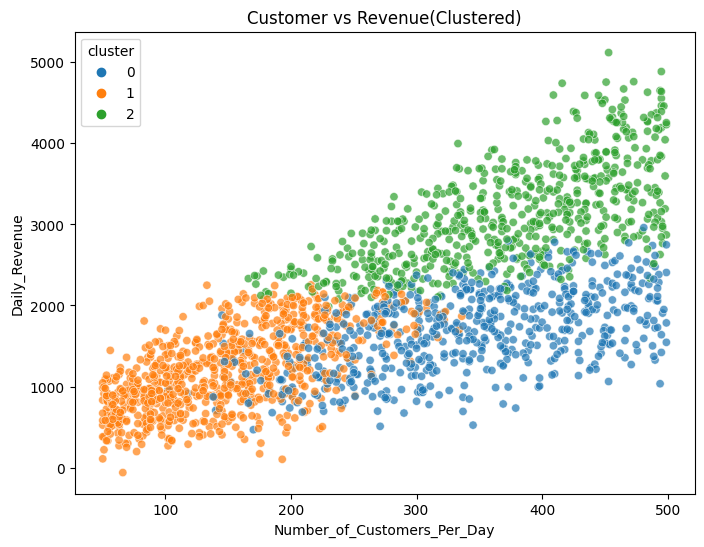

In [14]:
cluster_features = ['Number_of_Customers_Per_Day','Average_Order_Value','Number_of_Employees','Marketing_Spend_Per_Day','Location_Foot_Traffic','Daily_Revenue']
from sklearn.preprocessing import StandardScaler
scaler_clust = StandardScaler()
clust_scaled = scaler_clust.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(clust_scaled)

cluster_profile = df.groupby('cluster')[cluster_features].mean().round(2)
display(cluster_profile)

plt.figure(figsize=(8,6))
sns.scatterplot(data = df, x = 'Number_of_Customers_Per_Day', y='Daily_Revenue', 
                hue='cluster', palette='tab10', alpha=0.7)
plt.title('Customer vs Revenue(Clustered)')
plt.show()

Cluster 0: high traffic but low-conversion, price sensitive markets

Cluster 1: Low foot trafic, medium to high average transaction value, stable but small-scale

Cluster 2 : Marketing and revenue exhibit a strong positive correlation


**Optimization**

In [15]:
median_row = df.median().to_dict()

def predict_rev_with_settings(num_emp, marketing_spend, baseline_row, rf_model, scaler_poly=None):
    # employee and marketing spend
    vec = baseline_row.copy()
    vec['Number_of_Employees'] = num_emp
    vec['Marketing_Spend_Per_Day'] = marketing_spend
    vec['rev_per_employee'] = vec['Daily_Revenue'] / max(num_emp,1)
    vec['effective_traffic'] = vec['Location_Foot_Traffic'] * vec['Operating_Hours_Per_Day']
    vec['marketing_per_customer'] = vec['Marketing_Spend_Per_Day'] / (vec['Number_of_Customers_Per_Day'] + 1)
    vec['customer_spend'] = vec['Number_of_Customers_Per_Day'] * vec['Average_Order_Value']
    # 构建 DataFrame
    row = pd.DataFrame([vec])[feature_cols]
    # RF 训练使用原始特征（未 scaled），因此直接预测
    pred = rf_model.predict(row)[0]
    return pred


budget = 500  # assume budget in labor + marketing
best = None
for emp in range(2, 16):
    labor_cost = emp * 100  # each employee daily cost = 100
    for m in range(10, 501, 10):
        if labor_cost + m > budget:
            continue
        pred_rev = predict_rev_with_settings(emp, m, median_row, rf)
        profit_est = pred_rev - labor_cost - m
        if best is None or profit_est > best[0]:
            best = (profit_est, emp, m, pred_rev)
print("Optimization result (under budget):", best)

Optimization result (under budget): (1699.1510499999977, 2, 290, 2189.1510499999977)


Marketing resources should be prioritized for Cluster 2(which with highest Ads ROI)

**Causal Inference**

In [16]:
#Attempt to estimate whether high marketing (treatment) has a causal effect on income based on observational data.

threshold = df['Marketing_Spend_Per_Day'].quantile(0.7)
df['high_marketing'] = (df['Marketing_Spend_Per_Day'] >= threshold).astype(int)

covariates = ['Number_of_Customers_Per_Day','Average_Order_Value','Operating_Hours_Per_Day','Number_of_Employees','Location_Foot_Traffic']
ps_model = LogisticRegression(max_iter=500)
ps_model.fit(df[covariates], df['high_marketing'])
df['propensity'] = ps_model.predict_proba(df[covariates])[:,1]

treated = df[df['high_marketing']==1].reset_index(drop=True)
control = df[df['high_marketing']==0].reset_index(drop=True)
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity']])
dist, idx = nn.kneighbors(treated[['propensity']])
control_matches = control.iloc[idx.flatten()].reset_index(drop=True)
treated_reset = treated.reset_index(drop=True)

att = (treated_reset['Daily_Revenue'].values - control_matches['Daily_Revenue'].values).mean()
print(f"Estimated ATT of high marketing (PSM nearest neighbor): {att:.2f} dollars")

balance = pd.concat([treated_reset[covariates].mean(), control_matches[covariates].mean()], axis=1)
balance.columns = ['treated_mean','matched_control_mean']
display(balance)

Estimated ATT of high marketing (PSM nearest neighbor): 374.77 dollars


,treated_mean,matched_control_mean
Number_of_Customers_Per_Day,281.276667,280.546667
Average_Order_Value,6.260717,6.320483
Operating_Hours_Per_Day,11.690000,11.473333
Number_of_Employees,8.120000,8.185000
Location_Foot_Traffic,534.283333,536.148333


High marketing brings $374.77 per day compare with low markeitng stores.

Limited marginal growth indicates that marketing effectiveness has reached its ceiling.

# Business Strategy Development

**Queueing Theory**

In [17]:
# arrival_rate_per_hour = Number_of_Customers_Per_Day / Operating_Hours

df["arrival_rate"] = df["Number_of_Customers_Per_Day"] / df["Operating_Hours_Per_Day"]

service_rate = 1 / 0.0667   # assume it's 4mins, -- > per hour
df["service_rate_per_employee"] = service_rate

In [18]:
import numpy as np
import pandas as pd
from math import factorial

def mm_s_wait_time(arrival_rate, service_rate, s):
    rho = arrival_rate / (s * service_rate)
    if rho >= 1:
        return np.inf, np.inf, rho
    
    # P0 : probability of zero customers
    sum_terms = sum((arrival_rate/service_rate)**k / factorial(k) for k in range(s))
    last_term = ((arrival_rate/service_rate)**s / factorial(s)) * (1 / (1 - rho))
    P0 = 1 / (sum_terms + last_term)

    # Lq : expected number in queue
    Lq = (P0 * ((arrival_rate/service_rate)**s) * rho) / (factorial(s) * (1 - rho)**2)

    Wq = Lq / arrival_rate              # average wait time
    W = Wq + 1/service_rate             # total time in system
    
    return Wq, W, rho


results = df.apply(
    lambda row: mm_s_wait_time(
        row["arrival_rate"], 
        row["service_rate_per_employee"], 
        int(row["Number_of_Employees"])
    ), 
    axis=1
)

df["Wq_wait_time_hours"] = results.apply(lambda x: x[0])
df["W_total_time_hours"] = results.apply(lambda x: x[1])
df["utilization_rho"] = results.apply(lambda x: x[2])

df[["Number_of_Customers_Per_Day","Number_of_Employees",
    "arrival_rate","utilization_rho","Wq_wait_time_hours"]].head(10)

,Number_of_Customers_Per_Day,Number_of_Employees,arrival_rate,utilization_rho,Wq_wait_time_hours
0,152,4,10.857143,0.181043,1.380566e-04
1,485,8,40.416667,0.336974,8.850532e-05
2,398,6,66.333333,0.737406,1.689457e-02
3,320,4,18.823529,0.313882,1.040570e-03
4,156,2,9.176471,0.306035,6.892497e-03
5,121,9,20.166667,0.149457,1.060208e-07
6,238,4,21.636364,0.360786,1.728078e-03
7,70,3,7.000000,0.155633,3.314615e-04
8,152,2,10.857143,0.362086,1.006426e-02
9,171,5,24.428571,0.325877,5.494150e-04


rhp > 0.8      Long waits            Insufficient capacity

0.4<rho<0.7    Short wait            Good operation

rho< 0.3       No waiting needed     Over capacity

In [19]:
#conversion = customers / foot_traffic

df["conversion_rate"] = df["Number_of_Customers_Per_Day"] / df["Location_Foot_Traffic"]
df["conversion_rate"].replace([np.inf, -np.inf], np.nan, inplace=True)

**Queueing Theory**

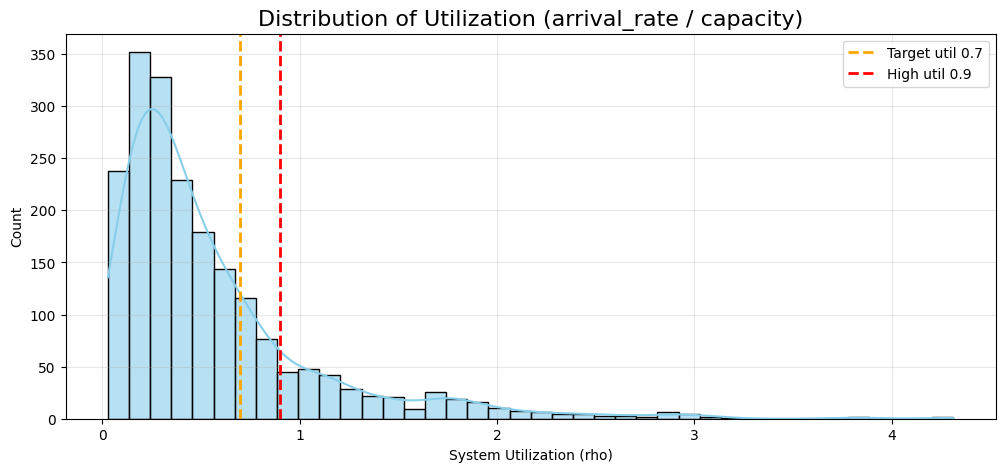

In [20]:
# arrival rate (λ) = customers per day / operating hours
df["arrival_rate"] = df["Number_of_Customers_Per_Day"] / df["Operating_Hours_Per_Day"]

# service rate per employee 
service_rate_per_employee = 8  

df["service_capacity"] = df["Number_of_Employees"] * service_rate_per_employee
# utilization ρ = λ / μ
df["rho"] = df["arrival_rate"] / df["service_capacity"]

plt.figure(figsize=(12,5))
sns.histplot(df["rho"], kde=True, bins=40, color="skyblue", alpha=0.6)

plt.axvline(0.7, color="orange", linestyle="--", linewidth=2, label="Target util 0.7")
plt.axvline(0.9, color="red", linestyle="--", linewidth=2, label="High util 0.9")

plt.title("Distribution of Utilization (arrival_rate / capacity)", fontsize=16)
plt.xlabel("System Utilization (rho)")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

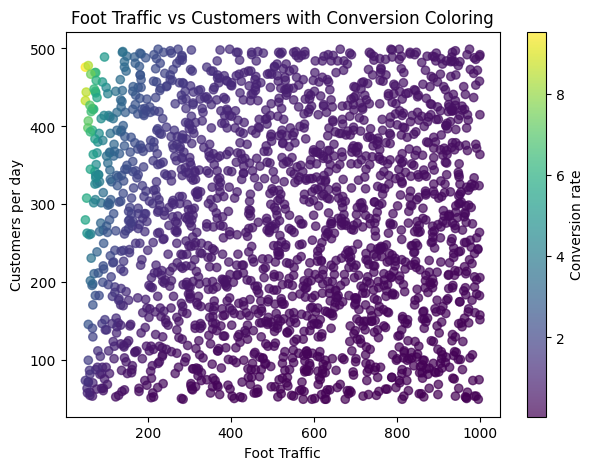

In [21]:
plt.figure(figsize=(7,5))
plt.scatter(
    df["Location_Foot_Traffic"],
    df["Number_of_Customers_Per_Day"],
    c=df["conversion_rate"],
    cmap="viridis",
    alpha=0.7
)
plt.colorbar(label="Conversion rate")
plt.xlabel("Foot Traffic")
plt.ylabel("Customers per day")
plt.title("Foot Traffic vs Customers with Conversion Coloring")
plt.show()

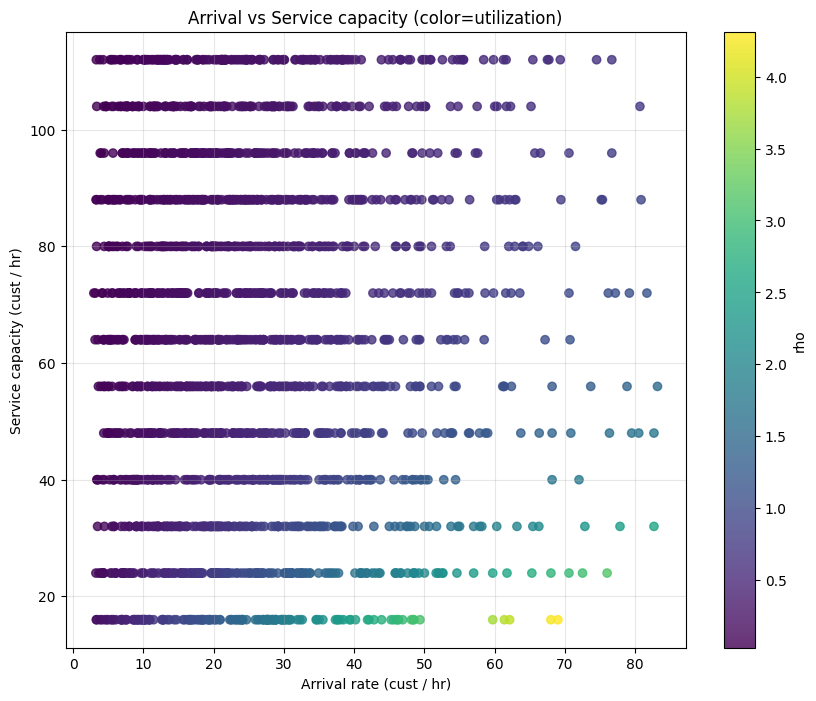

In [22]:
plt.figure(figsize=(10,8))
scatter = plt.scatter(
    df["arrival_rate"],
    df["service_capacity"],
    c=df["rho"],
    cmap="viridis",
    alpha=0.8
)

plt.colorbar(scatter, label="rho")
plt.xlabel("Arrival rate (cust / hr)")
plt.ylabel("Service capacity (cust / hr)")
plt.title("Arrival vs Service capacity (color=utilization)")
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
high_foot = df["Location_Foot_Traffic"].quantile(0.75)
low_conv = df["conversion_rate"].quantile(0.25)

df_outliers = df[(df["Location_Foot_Traffic"] >= high_foot) & 
                 (df["conversion_rate"] <= low_conv)]

df_outliers.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue,cluster,high_marketing,propensity,arrival_rate,service_rate_per_employee,Wq_wait_time_hours,W_total_time_hours,utilization_rho,conversion_rate,service_capacity,rho
8,152,8.78,14,2,341.79,825,1704.94,1,0,0.264956,10.857143,14.992504,1.006426e-02,0.076764,0.362086,0.184242,16,0.678571
14,149,9.11,15,2,446.58,907,1707.13,1,1,0.265242,9.933333,14.992504,8.222289e-03,0.074922,0.331277,0.164278,16,0.620833
18,199,3.47,11,2,90.17,887,962.96,1,0,0.268337,18.090909,14.992504,3.817574e-02,0.104876,0.603332,0.224352,16,1.130682
35,108,8.21,12,2,468.73,849,1526.31,1,1,0.258564,9.000000,14.992504,6.603955e-03,0.073304,0.300150,0.127208,16,0.562500
37,237,9.72,11,13,95.64,986,2441.69,2,0,0.313343,21.545455,14.992504,2.759286e-11,0.066700,0.110545,0.240365,104,0.207168


In [24]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = df[["Location_Foot_Traffic"]]
y = df["Daily_Revenue"]

model = LinearRegression()
model.fit(X, y)

coef = model.coef_[0]
intercept = model.intercept_

print("Revenue increase per +1 foot traffic:", coef)
print("Regression equation: Rev = {:.2f} * FootTraffic + {:.2f}".format(coef, intercept))

Revenue increase per +1 foot traffic: 0.04839854003915296
Regression equation: Rev = 0.05 * FootTraffic + 1891.44


In [25]:
df["elasticity"] = (coef * df["Location_Foot_Traffic"]) / df["Daily_Revenue"]
df["elasticity"].describe()

count    2000.000000
mean        0.018534
std         0.021983
min        -0.408042
25%         0.007340
50%         0.013634
75%         0.023356
max         0.349339
Name: elasticity, dtype: float64

Foot traffice revenue: 

    Location elasticity >1, foot traffice brings more revenue

    Location elasticity < 0.3(less customer but high revenue): Premium zone